# 01 · Generating the training dataset

ControlBench's ML models learn to imitate the exact controller comparison. To give them ground truth, we generate thousands of **random stable plants**, run the full comparison on each, and record

> plant features  →  (winning controller, its settling time, its overshoot).

Stable plants are built by **placing poles** in the left-half plane and expanding to a polynomial, which guarantees stability by construction and yields a realistic spread of damping ratios and natural frequencies.

In [1]:
# Make the controlbench package importable when running from notebooks/
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from controlbench.ml import random_stable_plant, generate_dataset
from controlbench.ml.features import FEATURE_NAMES

### A single random plant
Every draw is stable — all poles have negative real parts.

In [3]:
rng = np.random.default_rng(0)
p = random_stable_plant(rng)
print('num:', p.num, ' den:', p.den)
print('poles:', np.round(p.poles, 3))
print('stable:', p.is_stable, ' order:', p.order,
      ' zeta:', round(p.damping_ratio, 3), ' wn:', round(p.natural_frequency, 3))

num: (1.4099536636507697,)  den: (1.0, 4.216703435335057, 0.7063742631715186, 0.995682849156532)
poles: [-4.104+0.j    -0.057+0.489j -0.057-0.489j]
stable: True  order: 3  zeta: 0.115  wn: 0.493


### Generate a sample
Here we build a small sample to visualise. The **full** dataset used downstream (2000 rows) is produced by `python scripts/build_ml.py` (or set `N = 2000` below — it takes ~3 minutes because each row runs a full simulation).

In [4]:
N = 300
df = generate_dataset(N, seed=42)
df.head()

,order,damping_ratio,natural_frequency,dc_gain,den_a1,den_a2,den_a3,num_s,num_1,best_controller,best_settling_time,best_overshoot,best_score
0,1.0,1.0,2.306617,0.775117,2.306617,0.000000,0.000000,0.000000,1.787897,P,0.714209,0.000000,0.924092
1,3.0,1.0,0.652051,0.249881,8.478631,20.413588,9.983073,1.056197,2.494582,P,2.406962,0.000000,0.933023
2,1.0,1.0,3.290553,0.527006,3.290553,0.000000,0.000000,0.000000,1.734142,P,0.500648,0.000000,0.928430
3,3.0,1.0,0.506323,1.527580,2.130385,2.693784,0.947575,0.000000,1.447497,PID,9.074830,30.740602,0.757605
4,1.0,1.0,1.901725,1.028565,1.901725,0.000000,0.000000,0.000000,1.956047,P,0.866270,0.000000,0.920180


### What the labels look like

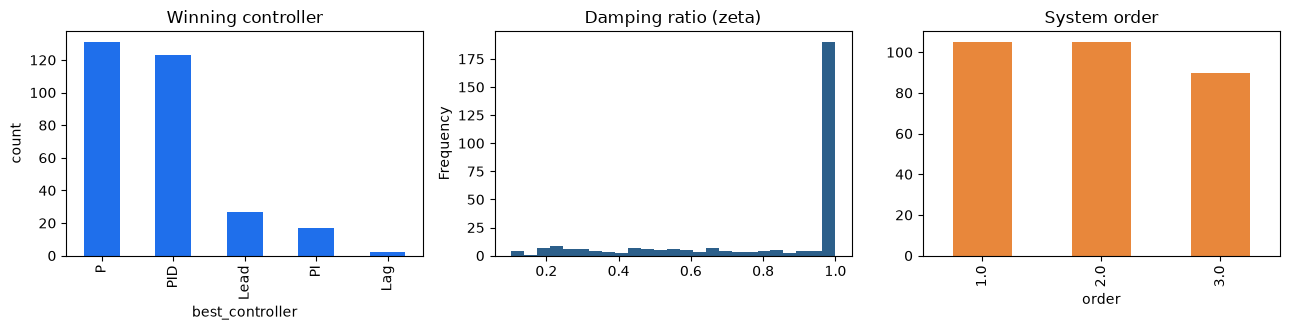

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
df['best_controller'].value_counts().plot.bar(ax=ax[0], color='#1f6feb')
ax[0].set_title('Winning controller'); ax[0].set_ylabel('count')
df['damping_ratio'].plot.hist(ax=ax[1], bins=25, color='#2c5f8a')
ax[1].set_title('Damping ratio (zeta)')
df['order'].value_counts().sort_index().plot.bar(ax=ax[2], color='#e8873b')
ax[2].set_title('System order')
plt.tight_layout(); plt.show()

The class balance is uneven — some controllers win far more often than others. That is a real property of the problem (PID and P are frequently the best all-round choice), and the classifier in notebook 02 has to cope with it.